In [1]:
import requests,json
import pandas as pd
import numpy as np

In [2]:
with open('C:/Users/USER/Desktop/Sentiment/Sentiment_Analysis/ugandan_comments.json', 'r', encoding='utf-8')as file:
    data = json.load(file)

In [3]:
#Checking the type of data
if isinstance(data, list):
    comments_list = data
    print("Data is a list")
elif isinstance(data, dict) and 'comments' in data:
    comments_list = data['comments']
    print("Data is a dictionary")
else:
    comments_list = data

df = pd.DataFrame(comments_list)

print(f"\n DataFrame created with {df.shape} rows and columns")
print(f"\n Columns: {df.columns.tolist()}")
print(df.head())

Data is a list

 DataFrame created with (4000, 17) rows and columns

 Columns: ['videoWebUrl', 'submittedVideoUrl', 'input', 'cid', 'createTime', 'createTimeISO', 'text', 'diggCount', 'likedByAuthor', 'pinnedByAuthor', 'repliesToId', 'replyCommentTotal', 'uid', 'uniqueId', 'avatarThumbnail', 'mentions', 'detailedMentions']
                                         videoWebUrl  \
0  https://www.tiktok.com/@moshprofit/video/76196...   
1  https://www.tiktok.com/@moshprofit/video/76196...   
2  https://www.tiktok.com/@moshprofit/video/76196...   
3  https://www.tiktok.com/@moshprofit/video/76196...   
4  https://www.tiktok.com/@moshprofit/video/76196...   

                                   submittedVideoUrl  \
0  https://www.tiktok.com/@moshprofit/video/76196...   
1  https://www.tiktok.com/@moshprofit/video/76196...   
2  https://www.tiktok.com/@moshprofit/video/76196...   
3  https://www.tiktok.com/@moshprofit/video/76196...   
4  https://www.tiktok.com/@moshprofit/video/76196...   

 

In [4]:
#Extract the  comments (text) from the dataframe
comments = df['text']
comments

0        Besides being a president he is also a dentist 🤣
1                             Ebyo byebiruma Bebe cooling
2                                               happy fam
3             The way I like this family I don't know 🥰🥰🥰
4       Ono omusajjja mu maaso gange talisobya\nalways...
                              ...                        
3995                                       long live mzee
3996                                      My president 🇺🇬
3997                                  The man of his word
3998                                  is education there?
3999                               For u do u hv a degree
Name: text, Length: 4000, dtype: object

In [5]:
# Cleaning the comments using regular expressions
import pandas as pd
import re


# slang mapping dictionary
slang_map = {
    'u': 'you',
    'ur': 'your',
    'r': 'are',
    'yall': 'you all',
    'ya': 'you',
    'yh': 'yeah',
    'yep': 'yes',
    'nope': 'no',
    'coz': 'because',
    'wanna': 'want to',
    'gonna': 'going to',
    'hv': 'have',
    'fam': 'friend',
}

#This cleaned version for word frequency in order to find out the themes and topics
def clean_text(text):
    if pd.isna(text):
        return ''

    text = str(text).lower()

    text = re.sub(r'\[.*?\]', '', text)
    # removes emojis
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # Emoticons
        "\U0001F300-\U0001F5FF"  # Symbols & pictographs
        "\U0001F680-\U0001F6FF"  # Transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # Flags (iOS)
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "\U0001f926-\U0001f937"
        "\U00010000-\U0010ffff"
        "\u2640-\u2642"
        "\u2600-\u2B55"
        "\u200d"
        "\u23cf"
        "\u23e9"
        "\u231a"
        "\ufe0f"  # Dingbats
        "\u3030"
        "]+",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)

    # Remove special Unicode space characters (like the 'ᅠ' you found)
    # This includes Hangul filler, mongolian vowel separator, etc.
    special_spaces = re.compile(r'[\u115F\u1160\u3164\uFFA0\u200B-\u200F\u2028-\u202F\u205F\u3000]')
    text = special_spaces.sub(r' ', text)
    # remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    
    # remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (optional - keep if you want)
    text = re.sub(r'#\w+', '', text)
    
    # Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

   #split to words
    words = text.split()
    
    mapped_words = [slang_map.get(word, word) for word in words]
    
    
    return ' '.join(mapped_words)

#this is for word frequency
df['clean_text'] = df['text'].apply(clean_text)


for i in range(min(5, len(df))):
    print(f"\nOriginal text: {df['text'].iloc[i]}")
    print(f"\nCleaned text: {df['clean_text'].iloc[i]}")



Original text: Besides being a president he is also a dentist 🤣

Cleaned text: besides being a president he is also a dentist

Original text: Ebyo byebiruma Bebe cooling

Cleaned text: ebyo byebiruma bebe cooling

Original text: happy fam

Cleaned text: happy friend

Original text: The way I like this family I don't know 🥰🥰🥰

Cleaned text: the way i like this family i don't know

Original text: Ono omusajjja mu maaso gange talisobya
always perfect

Cleaned text: ono omusajjja mu maaso gange talisobya always perfect


In [6]:

#And then this for Vader sentiment analysis since it cosiders emojis to produce better sentiment analysis
def clean_for_sentiment(text):
    """Cleaning that PRESERVES emojis for VADER"""
    if pd.isna(text):
        return ''
    
    text = str(text) 
    
    # Remove bracket content (sticker markers)
    text = re.sub(r'\[.*?\]', '', text)
    
    # Remove special Unicode spaces
    special_spaces = re.compile(r'[\u115F\u1160\u3164\uFFA0\u200B-\u200F\u2028-\u202F\u205F\u3000]')
    text = special_spaces.sub(r' ', text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    
    # Remove mentions (but keep emojis)
    text = re.sub(r'@\w+', '', text)
    
    # Keep hashtags but remove the # symbol (VADER understands words)
    text = re.sub(r'#', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    
    words = text.split()
    mapped_words = [slang_map.get(word.lower(), word) for word in words]
    
    return ' '.join(mapped_words)


# Create a sentiment-specific cleaned column (keeps emojis)
df['sentiment_text'] = df['text'].apply(clean_for_sentiment)

In [7]:
%pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
#here am finding the top 10 frequent words
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')

#first remove the stopwords in order to give meaning to the task
stops = set(stopwords.words('english'))


all_text = ' '.join(df['clean_text'].astype(str))
words = all_text.split()

filtered_words = [word.lower() for word in words if word.lower() not in stops]
word_freq = Counter(filtered_words) 
#Find the most top 10 frequent words
print(word_freq.most_common(15))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...


[('love', 168), ('like', 164), ('uganda', 164), ('one', 121), ('president', 109), ('god', 100), ('yes', 97), ('know', 89), ('us', 82), ('even', 81), ('people', 80), ('good', 78), ('museveni', 75), ('never', 75), ('please', 74)]


In [15]:
from nltk.util import ngrams
from collections import Counter
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

political_keywords = ['president', 'museveni', 'm7', 'mzee']
president_bigrams = []
president_trigrams = []
president_fourgrams = []
president_fivegrams = []
museveni_bigrams = []
museveni_trigrams = []
museveni_fourgrams = []
museveni_fivegrams = []

political_sentiment_phrase = []

for text in df['clean_text']:
    words = text.lower().split()
    if len(words) < 1:
        continue

    bigrams = list(ngrams(words,2))
    trigrams = list(ngrams(words,3))
    four_grams = list(ngrams(words, 4))
    five_grams = list(ngrams(words, 5))
                      
    for bigram  in bigrams:
        bigram_text=' '.join(bigram)
        if 'museveni' in bigram_text or 'president' in bigram_text or 'm7' in bigram_text or 'mzee' in bigram_text:
            sentiment = sia.polarity_scores(bigram_text)['compound']
            political_sentiment_phrase.append((bigram_text, sentiment, 'bigram'))

        if 'president' in bigram_text:
            president_bigrams.append(bigram)
        if 'museveni' in bigram_text or 'm7' in bigram_text or 'mzee' in bigram_text:
            museveni_bigrams.append(bigram)

                     
    for trigram  in trigrams:
        trigram_text=' '.join(bigram)
        if 'museveni' in trigram_text or 'president' in trigram_text or 'm7' in trigram_text or 'mzee' in trigram_text:
            sentiment = sia.polarity_scores(trigram_text)['compound']
            political_sentiment_phrase.append((trigram_text, sentiment, 'trigram'))

        if 'president' in trigram_text:
            president_trigrams.append(trigram)
        if 'museveni' in trigram_text or 'm7' in trigram_text or 'mzee' in trigram_text:
            museveni_trigrams.append(trigram)

                     
    for four_gram  in four_grams:
        four_gram_text=' '.join(four_gram)
        if 'museveni' in four_gram_text or 'president' in four_gram_text or 'm7' in four_gram_text or 'mzee' in four_gram_text:
            sentiment = sia.polarity_scores(four_gram_text)['compound']
            political_sentiment_phrase.append((four_gram_text, sentiment, 'four_gram'))

        if 'president' in four_gram_text:
            president_fourgrams.append(four_gram)
        if 'museveni' in four_gram_text or 'm7' in four_gram_text or 'mzee' in four_gram_text:
            museveni_fourgrams.append(four_gram)        

                     
    for five_gram  in five_grams:
        five_gram_text=' '.join(five_gram)
        if 'museveni' in five_gram_text or 'president' in five_gram_text or 'm7' in five_gram_text or 'mzee' in five_gram_text:
            sentiment = sia.polarity_scores(five_gram_text)['compound']
            political_sentiment_phrase.append((five_gram_text, sentiment, 'five_gram'))

        if 'president' in five_gram_text:
            president_fivegrams.append(five_gram)
        if 'museveni' in five_gram_text or 'm7' in five_gram_text or 'mzee' in five_gram_text:
            museveni_fivegrams.append(five_gram)


# Get frequency counts
president_bigram_freq = Counter(president_bigrams)
president_trigram_freq = Counter(president_trigrams)
president_fourgram_freq = Counter(president_fourgrams)
president_fivegram_freq = Counter(president_fivegrams)
museveni_bigram_freq = Counter(museveni_bigrams)
museveni_trigram_freq = Counter(museveni_trigrams)
museveni_fourgram_freq = Counter(museveni_fourgrams)
museveni_fivegram_freq = Counter(museveni_fivegrams)

print("\n📊 TOP BIGRAMS with 'president':")
for bigram, count in president_bigram_freq.most_common(15):
    print(f"  • {' '.join(bigram)}: {count} times")
print("\n📊 TOP TRIGRAMS with 'president':")
for trigram, count in president_trigram_freq.most_common(15):
    print(f"  • {' '.join(trigram)}: {count} times")

print("\n📊 TOP FOUR_GRAMS with 'president':")
for fourgram, count in president_fourgram_freq.most_common(15):
    print(f"  • {' '.join(fourgram)}: {count} times")

print("\n📊 TOP FIVEGRAMS with 'president':")    
for fivegram, count in president_fivegram_freq.most_common(15):
    print(f"  • {' '.join(fivegram)}: {count} times")

print("\n" + "="*70)
print("N_GRAMS WITH 'museveni in it!'")
print("="*70)

    
print("\n📊 TOP BIGRAMS with 'museveni':")
for bigram, count in museveni_bigram_freq.most_common(15):
    print(f"  • {' '.join(bigram)}: {count} times")

print("\n📊 TOP TRIGRAMS with 'museveni':")
for trigram, count in museveni_trigram_freq.most_common(15):
    print(f"  • {' '.join(trigram)}: {count} times")

print("\n📊 TOP FOUR_GRAMS with 'museveni':")
for fourgram, count in museveni_fourgram_freq.most_common(15):
    print(f"  • {' '.join(fourgram)}: {count} times")

print("\n📊 TOP FIVEGRAMS with 'museveni':")    
for fivegram, count in museveni_fivegram_freq.most_common(15):
    print(f"  • {' '.join(fivegram)}: {count} times")


📊 TOP BIGRAMS with 'president':
  • my president: 28 times
  • president museveni: 15 times
  • our president: 13 times
  • mr president: 12 times
  • president of: 9 times
  • live president: 7 times
  • the president: 5 times
  • first president: 4 times
  • president m7: 4 times
  • president and: 3 times
  • president forever: 3 times
  • a president: 2 times
  • president may: 2 times
  • only president: 2 times
  • president i: 2 times

📊 TOP TRIGRAMS with 'president':
  • that's my president: 5 times
  • long live president: 5 times
  • you mr president: 4 times
  • long live our: 2 times
  • live our president: 2 times
  • my president forever: 2 times
  • live president m7: 2 times
  • live president museveni: 2 times
  • we love our: 2 times
  • long live my: 2 times
  • live my president: 2 times
  • he miss his: 1 times
  • miss his family: 1 times
  • his family our: 1 times
  • family our president: 1 times

📊 TOP FOUR_GRAMS with 'president':
  • long live president muse

In [16]:
# this gets sentiment for the whole comment with emojis
# Add sentiment for ENTIRE comments
df['comment_sentiment'] = df['sentiment_text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

# Add sentiment labels
df['sentiment_label'] = df['comment_sentiment'].apply(
    lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral')
)

sentiment_counts = df['sentiment_label'].value_counts()

for label in ['positive', 'neutral', 'negative']:
    if label in sentiment_counts:
        count = sentiment_counts[label]
        pct = (count/len(df))*100
        print(f" {label} : {count}comments ({pct:.1f})%")
        
# Show examples
print("\n EXAMPLE COMMENTS WITH THEIR SENTIMENT:")
print("-"*50)

print("\n NEGATIVE comment example:")
negative_example = df[df['sentiment_label'] == 'negative']['sentiment_text'].iloc[0]
negative_score = df[df['sentiment_label'] == 'negative']['comment_sentiment'].iloc[0]
print(f"  Score: {negative_score:.2f}")
print(f"  {negative_example[:150]}...")

print("\n POSITIVE comment example:")
positive_example = df[df['sentiment_label'] == 'positive']['sentiment_text'].iloc[0]
positive_score = df[df['sentiment_label'] == 'positive']['comment_sentiment'].iloc[0]
print(f"  Score: {positive_score:.2f}")
print(f"  {positive_example[:150]}...")

print("\n NEUTRAL comment example:")
neutral_example = df[df['sentiment_label'] == 'neutral']['sentiment_text'].iloc[0]
neutral_score = df[df['sentiment_label'] == 'neutral']['comment_sentiment'].iloc[0]
print(f"  Score: {neutral_score:.2f}")
print(f"  {neutral_example[:150]}...")

 positive : 1635comments (40.9)%
 neutral : 2029comments (50.7)%
 negative : 336comments (8.4)%

 EXAMPLE COMMENTS WITH THEIR SENTIMENT:
--------------------------------------------------

 NEGATIVE comment example:
  Score: -0.15
  he miss his family our president...

 POSITIVE comment example:
  Score: 0.78
  happy friend...

 NEUTRAL comment example:
  Score: 0.00
  Besides being a president he is also a dentist 🤣...


In [17]:
from textblob import TextBlob

# Function to get subjectivity
def get_subjectivity(text):
    if pd.isna(text) or text.strip() == '':
        return 0.0
    try:
        blob = TextBlob(str(text))
        return blob.sentiment.subjectivity  # 0 = fact, 1 = opinion
    except:
        return 0.0

# Add subjectivity column
df['subjectivity'] = df['sentiment_text'].apply(get_subjectivity)

# Categorize
df['fact_or_opinion'] = df['subjectivity'].apply(
    lambda x: 'Fact' if x < 0.3 else ('Opinion' if x > 0.6 else 'Mixed')
)

# Check distributiona
print("Fact vs Opinion Distribution:")
print(df['fact_or_opinion'].value_counts())
print(df['fact_or_opinion'].value_counts(normalize=True))

Fact vs Opinion Distribution:
fact_or_opinion
Fact       2561
Mixed       770
Opinion     669
Name: count, dtype: int64
fact_or_opinion
Fact       0.64025
Mixed      0.19250
Opinion    0.16725
Name: proportion, dtype: float64


In [18]:
#Add word count
df['word_count'] = df['clean_text'].str.split().str.len()
columns_added = ['comment_sentiment', 'sentiment_label', 'word_count']

for col in columns_added:
    if col in df.columns:
        print(f"\n{col}")
    else:
        print(f"{col} missing")

print(f"\nTotal rows and columns in dataframe {df.shape}")

summary_table = pd.DataFrame({
    'Metric': [
        'Total_comments',
        'Positive_comments',
        'Neutral_comments',
        'Negative_comments',
        'Positive_comments (%)',
        'Neutral_commments (%)',
        'Negative comments (%)',
        'Strongly Positive (>0.5)',
        'Strongly Negative (<-0.5)',
        'Avg_word count'
    ],
    'Value' :[
         len(df),
        f"{(df['sentiment_label'] == 'positive').sum()} comments",
        f"{(df['sentiment_label'] == 'neutral').sum()} comments",
        f"{(df['sentiment_label'] == 'negative').sum()} comments",
        f"{(df['sentiment_label'] == 'positive').mean()*100:.1f}%",
        f"{(df['sentiment_label'] == 'neutral').mean()*100:.1f}%",
        f"{(df['sentiment_label'] == 'negative').mean()*100:.1f}%",
        f"{(df['comment_sentiment'] >= 0.5).sum()} comments",
        f"{(df['comment_sentiment'] <= -0.5).sum()} comments",
        f"{df['word_count'].mean():.1f}"

    ]
})
summary_table.head(10)


comment_sentiment

sentiment_label

word_count

Total rows and columns in dataframe (4000, 24)


,Metric,Value
0,Total_comments,4000
1,Positive_comments,1635 comments
2,Neutral_comments,2029 comments
3,Negative_comments,336 comments
4,Positive_comments (%),40.9%
5,Neutral_commments (%),50.7%
6,Negative comments (%),8.4%
7,Strongly Positive (>0.5),765 comments
8,Strongly Negative (<-0.5),77 comments
9,Avg_word count,8.0


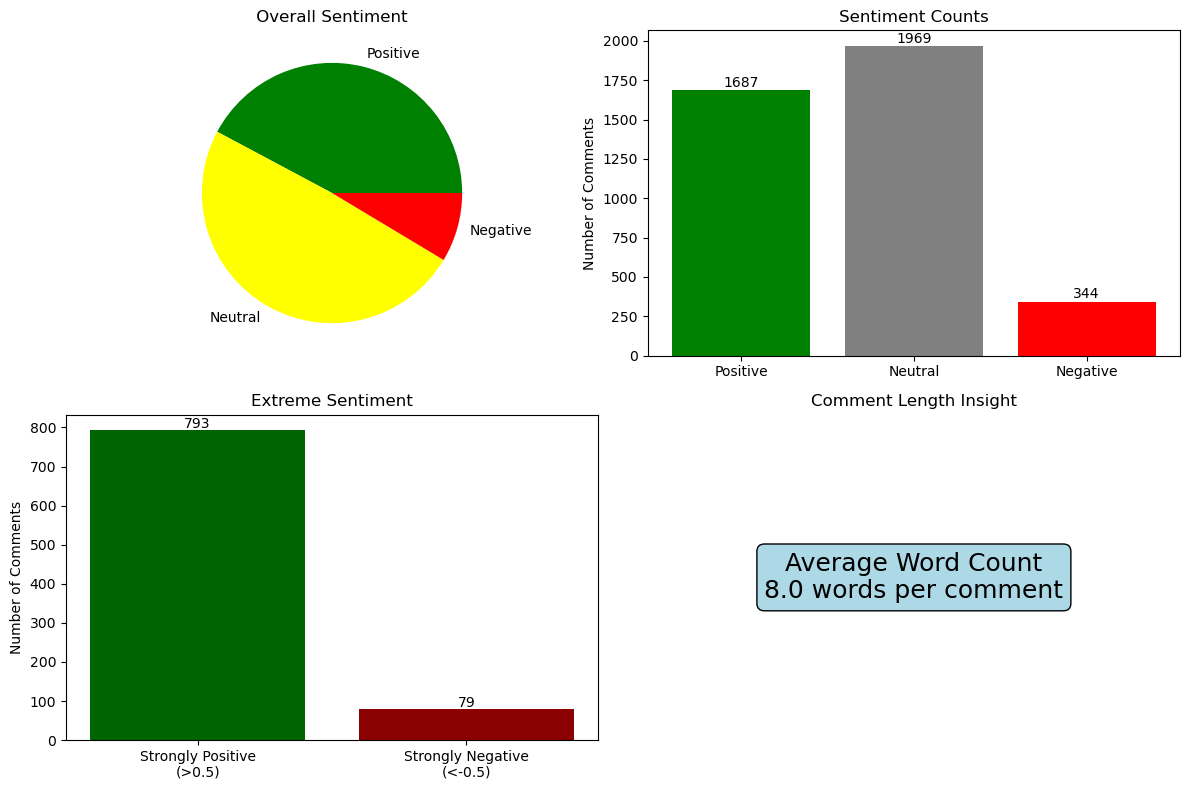

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12,8))
#Pie chart
axes[0,0].pie([42.2, 49.2, 8.6], labels = ['Positive', 'Neutral', 'Negative'], colors = ['green','yellow', 'red'])
axes[0,0].set_title(' Overall Sentiment ')

# Bar chart counts
axes[0,1].bar(['Positive', 'Neutral', 'Negative'], [1687, 1969, 344], 
              color=['green', 'gray', 'red'])
axes[0,1].set_ylabel('Number of Comments')
axes[0,1].set_title('Sentiment Counts')
for i, v in enumerate([1687, 1969, 344]):
    axes[0,1].text(i, v + 20, str(v), ha='center')

# Strong sentiment
axes[1,0].bar(['Strongly Positive\n(>0.5)', 'Strongly Negative\n(<-0.5)'], 
              [793, 79], color=['darkgreen', 'darkred'])
axes[1,0].set_ylabel('Number of Comments')
axes[1,0].set_title('Extreme Sentiment')
for i, v in enumerate([793, 79]):
    axes[1,0].text(i, v + 5, str(v), ha='center')

# Word count annotation
axes[1,1].text(0.5, 0.5, f'Average Word Count\n{8.0} words per comment', 
               ha='center', va='center', fontsize=18, 
               bbox=dict(boxstyle='round', facecolor='lightblue'))
axes[1,1].set_xlim(0,1)
axes[1,1].set_ylim(0,1)
axes[1,1].axis('off')
axes[1,1].set_title('Comment Length Insight')

plt.tight_layout()
plt.show()


In [32]:
def get_subjectivity(text):
    if pd.isna(text) or text.strip() == '':
        return 0.0
    try:
        blob = TextBlob(str(text))
        return blob.sentiment.subjectivity
    except:
        return 0.0

# Use 'sentiment_text' (with emojis) for best results
df['subjectivity'] = df['sentiment_text'].apply(get_subjectivity)

# Categorize subjectivity
df['subjectivity_label'] = df['subjectivity'].apply(
    lambda x: 'Factual' if x < 0.3 else ('Opinion' if x > 0.6 else 'Mixed')
)

print("\nSubjectivity Categories")
print(f"{df['subjectivity_label'].value_counts()}")


Subjectivity Categories
subjectivity_label
Factual    2561
Mixed       770
Opinion     669
Name: count, dtype: int64


In [42]:
# View mixed comments (0.3 to 0.6)
print("="*60)
print("MIXED COMMENTS (Contains Both Fact and Opinion)")
print("="*60)

mixed_comments = df[(df['subjectivity'] >= 0.3) & (df['subjectivity'] <= 0.6)][['sentiment_text', 'subjectivity_label', 'subjectivity', 'sentiment_label']]

# Randomly sample 10 comments (without replacement)
random_mixed = mixed_comments.sample(n=min(10, len(mixed_comments)), random_state=None)

for idx, row in random_mixed.iterrows():
    print(f"\n🔄 Subjectivity: {row['subjectivity']:.2f} | Subjectivity_label: {row['subjectivity_label']} | Sentiment: {row['sentiment_label']}")
    print(f"   Comment: {row['sentiment_text'][:200]}...")

MIXED COMMENTS (Contains Both Fact and Opinion)

🔄 Subjectivity: 0.54 | Subjectivity_label: Mixed | Sentiment: positive
   Comment: my mother gave it all and she is willing to do more nd more as long as she lives i cant think twice while giving to her infact i i can giv my life 4 h...

🔄 Subjectivity: 0.60 | Subjectivity_label: Mixed | Sentiment: positive
   Comment: Uganda 🇺🇬 I might be visiting there.. Not for anything else but the waterfall d the love for nature 🏞️...

🔄 Subjectivity: 0.60 | Subjectivity_label: Mixed | Sentiment: positive
   Comment: we love museveni...

🔄 Subjectivity: 0.60 | Subjectivity_label: Mixed | Sentiment: negative
   Comment: m literally crying because of mbidde🤣🤣🤣...

🔄 Subjectivity: 0.50 | Subjectivity_label: Mixed | Sentiment: negative
   Comment: Most proffessional jobs are there but if your not connected that’s where the problem starts from...

🔄 Subjectivity: 0.30 | Subjectivity_label: Mixed | Sentiment: neutral
   Comment: Real ones know he was even